In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
import pandas as pd 
import numpy as np
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt 
from tensorflow.keras import layers, models
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras import regularizers


In [2]:
train_dir = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train"
val_dir   = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val"
test_dir  = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test"

IMG_SIZE = (180,180)
BATCH_SIZE = 32


In [3]:
def load_dataset(path):
    ds = tf.keras.utils.image_dataset_from_directory(
        path,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )
    return ds.apply(tf.data.experimental.ignore_errors())  
train_ds = load_dataset(train_dir)
val_ds   = load_dataset(val_dir)
test_ds  = load_dataset(test_dir)

Found 9246 files belonging to 2 classes.
Found 829 files belonging to 2 classes.
Found 506 files belonging to 2 classes.


In [4]:
train_ds = train_ds.map(lambda x, y: (tf.cast(x, tf.float32)/255.0, y))
val_ds   = val_ds.map(lambda x, y: (tf.cast(x, tf.float32)/255.0, y))
test_ds  = test_ds.map(lambda x, y: (tf.cast(x, tf.float32)/255.0, y))


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

In [22]:
model = models.Sequential([

    layers.InputLayer(input_shape=(180,180,3)),

    # Block 1
    layers.Conv2D(32, 3, padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, 3, padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, 3, padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),


    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 180, 180, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    15,859,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,019,265 (61.11 MB)

 Trainable params: 16,019,265 (61.11 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)


Epoch 1/10
      3/Unknown 5s 44ms/step - accuracy: 0.4931 - loss: 0.7375

W0000 00:00:1773932170.818540     166 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


     29/Unknown 6s 34ms/step - accuracy: 0.4950 - loss: 0.7135

2026-03-19 14:56:11.620623: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 414/454


     37/Unknown 6s 33ms/step - accuracy: 0.5016 - loss: 0.7093

...

181/283 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9943 - loss: 0.0144

2026-03-19 14:58:05.033408: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 446/454


283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9946 - loss: 0.0140

2026-03-19 14:58:08.563163: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 446/454
2026-03-19 14:58:08.972260: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 446/454
2026-03-19 14:58:09.174122: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 414/454
2026-03-19 14:58:09.176446: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 414/454
2026-03-19 14:58:09.661689: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 446/454
2026-03-19 14:58:10.034654: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 446/454


283/283 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9946 - loss: 0.0140 - val_accuracy: 0.9890 - val_loss: 0.0401


In [25]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

      5/Unknown 1s 114ms/step - accuracy: 0.9975 - loss: 0.0084

2026-03-19 14:58:10.803899: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 446/454
2026-03-19 14:58:11.002358: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 414/454


     11/Unknown 1s 105ms/step - accuracy: 0.9922 - loss: 0.0160

2026-03-19 14:58:11.554389: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 446/454


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.9917 - loss: 0.0170
Test Accuracy: 0.9902439117431641


In [26]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = (preds > 0.39).astype("int32")

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

2026-03-19 14:58:12.000256: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 446/454
2026-03-19 14:58:12.057445: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 414/454
2026-03-19 14:58:12.423106: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 446/454


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


W0000 00:00:1773932292.714443     168 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
2026-03-19 14:58:12.854902: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 446/454


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


2026-03-19 14:58:12.959503: E tensorflow/core/lib/jpeg/jpeg_mem.cc:327] Premature end of JPEG data. Stopped at line 414/454


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step


<Figure size 600x600 with 0 Axes>

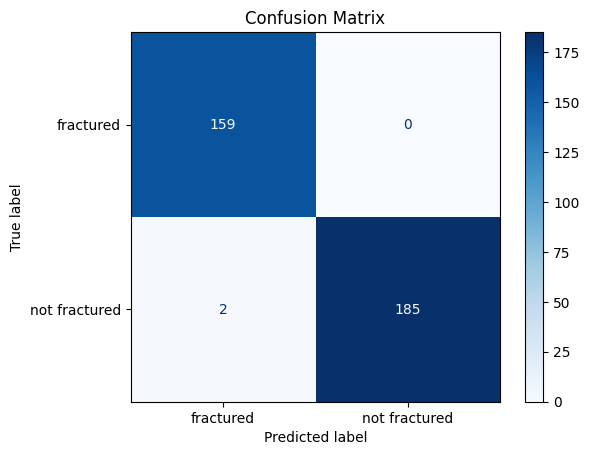

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["fractured", "not fractured"]
)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["fractured", "not fractured"]))

               precision    recall  f1-score   support

    fractured       0.99      1.00      0.99       159
not fractured       1.00      0.99      0.99       187

     accuracy                           0.99       346
    macro avg       0.99      0.99      0.99       346
 weighted avg       0.99      0.99      0.99       346



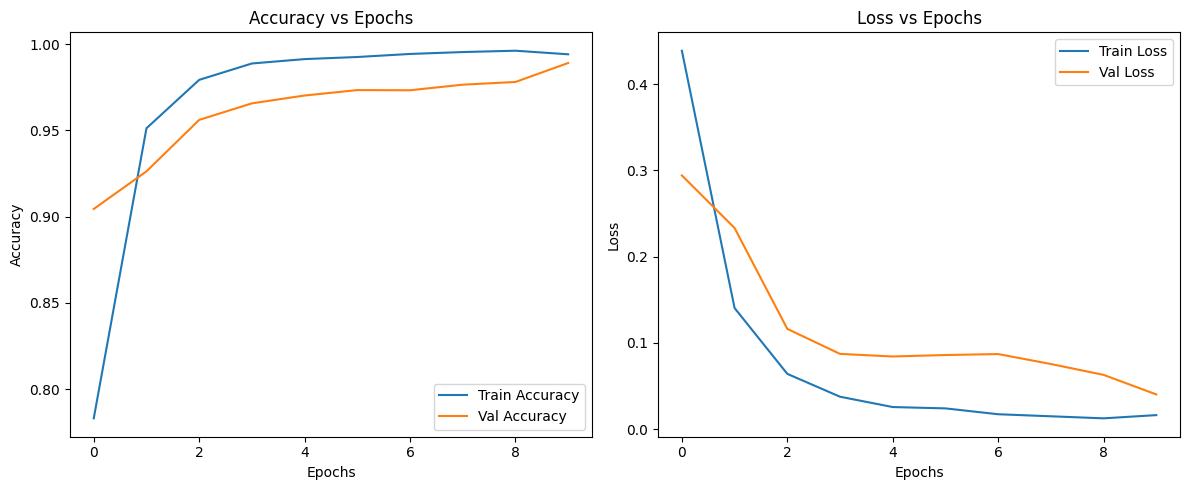

In [29]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
model.save("fracture_model.h5")

In [31]:
model = load_model("fracture_model.h5")   # or .h5

In [32]:
def preprocess_image(image_path, img_size=(180,180)):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(img_size)

    img_array = np.array(img)
    img_array = img_array / 255.0   # normalize

    img_array = np.expand_dims(img_array, axis=0)
    return img_array, img

In [33]:
def predict_image(image_path):
    processed_img, original_img = preprocess_image(image_path)

    prediction = model.predict(processed_img)[0][0]

    class_names = ["fractured", "not fractured"]

    label = class_names[int(prediction > 0.5)]
    confidence = prediction if prediction > 0.5 else 1 - prediction

    # Show result
    plt.imshow(original_img)
    plt.title(f"Prediction: {label}\nConfidence: {confidence:.2f}")
    plt.axis("off")
    plt.show()

    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step


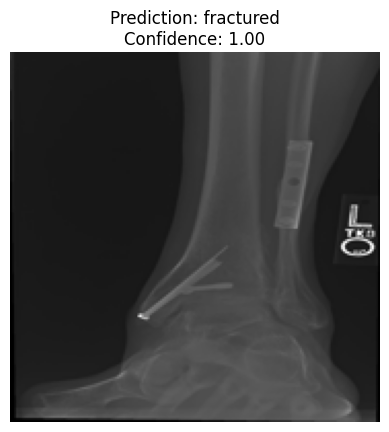

Prediction: fractured
Confidence: 1.0000


In [34]:
predict_image("/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/002555.png")